# 🔗 Integración del Sentimiento Transformer al EDA
### Complemento al notebook *EDA Analítica Educativa* · Equipo Tech Tailors
**Línea de trabajo NLP · Samsung Innovation Campus 2025**

Este notebook **complementa (no reemplaza)** el EDA del equipo: sustituye la clasificación
léxica manual de la sección 8 por el **sentimiento clasificado con 3 transformers en español**
(robertuito + BETO + XLM-R, votación por mayoría) más un **gold standard validado a mano**,
y re-evalúa los hallazgos del EDA que dependen del sentimiento:

| Sección | Qué re-evalúa | Del EDA |
|---|---|---|
| 3 | Comparación de los 3 esquemas de sentimiento (léxico / consenso / gold) | § 8.1 |
| 4 | ¿Sobreviven las "restricciones determinísticas"? | Insight 9 |
| 5 | ¿Cuánto desambigua el sentimiento la zona gris 3.4–3.9? | Insight 4 |
| 6 | Significancia de features con score gold | § 10 (SCRUM-8) |
| 7 | Regla híbrida (umbrales + sentimiento) vs ML | § 10.4 |
| 8 | Perfil docente con sentimiento gold | § 9 |


In [1]:
# --- Arranque: localizar la raíz del proyecto (para rutas e imports de src/) ---
import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'src').is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src import rutas
print('Raíz del proyecto:', RAIZ)

Raíz del proyecto: /Users/nato/Documents/Analisis de sentimiento


## 1 · Configuración

Misma identidad visual del EDA del equipo (paleta validada para daltonismo: ΔE CVD mínimo 23.8 entre pares adyacentes).

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Identidad visual del EDA TechTailors
COLOR_TENDENCIA = {'Mejora': '#0ca30c', 'Estable': '#2a78d6', 'En riesgo': '#d03b3b'}
COLOR_SENT = {'POS': '#0ca30c', 'NEU': '#898781', 'NEG': '#d03b3b'}
ORDEN_TENDENCIA = ['Mejora', 'Estable', 'En riesgo']
ORDEN_SENT = ['POS', 'NEU', 'NEG']
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#c3c2b7', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.6,
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.labelsize': 10, 'axes.labelcolor': INK2,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9,
})
pd.set_option('display.max_colwidth', 70)
print('Entorno listo | semilla =', RANDOM_STATE)

Entorno listo | semilla = 42


## 2 · Carga y verificación de integridad

Antes de usar los datos procesados verificamos que sean un espejo exacto del dataset original (mismas filas, mismo orden) y que el mapeo de sentimiento coincida con el gold standard.

In [3]:
df_orig = pd.read_csv(rutas.datos_raw())
df = pd.read_csv(rutas.datos_processed('evaluaciones_con_sentimiento.csv'))
gold = pd.read_csv(rutas.datos_processed('gold_standard_comentarios.csv'))
mapa = pd.read_csv(rutas.datos_processed('mapa_sentimiento_comentarios.csv'))

checks = {
    'Mismas dimensiones base (3000 x 9)':
        df_orig.shape == (3000, 9) and df.shape[0] == 3000,
    'Columnas originales idénticas fila a fila':
        all(df_orig[c].equals(df[c]) for c in df_orig.columns),
    'sentimiento_final coincide con el gold standard (20 comentarios)':
        df.drop_duplicates('comentario').set_index('comentario')['sentimiento_final']
          .eq(gold.set_index('comentario')['etiqueta_final']).all(),
    'sentimiento (consenso) coincide con mapa de modelos':
        df.drop_duplicates('comentario').set_index('comentario')['sentimiento']
          .eq(mapa.set_index('comentario')['sentimiento']).all(),
    'Sin NaN en columnas nuevas':
        df[['sentimiento', 'sentimiento_final', 'puntaje_promedio']].notna().all().all(),
}
for regla, ok in checks.items():
    print(f"{'✅' if ok else '❌'}  {regla}")
assert all(checks.values()), 'Integridad comprometida: revisar antes de continuar'

✅  Mismas dimensiones base (3000 x 9)
✅  Columnas originales idénticas fila a fila
✅  sentimiento_final coincide con el gold standard (20 comentarios)
✅  sentimiento (consenso) coincide con mapa de modelos
✅  Sin NaN en columnas nuevas


## 3 · Tres esquemas de sentimiento sobre los mismos 20 comentarios

* **Léxico EDA** — listas manuales POSITIVOS/NEGATIVOS de la sección 8.1 del EDA (resto neutro).
* **Consenso** — votación por mayoría de robertuito + BETO + XLM-R (transformers en español).
* **Gold** — consenso + 3 correcciones validadas a mano (estándar de referencia).

In [4]:
# Listas léxicas EXACTAS de la sección 8.1 del EDA del equipo
POSITIVOS_EDA = ['Excelente profesor, muy claro.', 'Explica muy bien los temas.',
                 'La clase es muy dinámica y entretenida.', 'Los talleres son muy útiles para aprender.',
                 'Me inspiró a seguir aprendiendo sobre este tema.', 'Resuelve las dudas con mucha paciencia.',
                 'Se nota que sabe mucho de la materia.']
NEGATIVOS_EDA = ['Califica de forma injusta.', 'Falta mucha pedagogía.',
                 'La clase es muy aburrida y monótona.', 'Llega tarde a las clases frecuentemente.',
                 'Los parciales no tienen nada que ver con lo visto en clase.',
                 'No explica bien, me siento perdido.', 'No resuelve las dudas de los estudiantes.']

df['sent_lexico'] = np.select(
    [df['comentario'].isin(POSITIVOS_EDA), df['comentario'].isin(NEGATIVOS_EDA)],
    ['POS', 'NEG'], default='NEU')

tabla20 = (df.groupby('comentario')
             .agg(frecuencia=('comentario', 'size'),
                  lexico_EDA=('sent_lexico', 'first'),
                  consenso=('sentimiento', 'first'),
                  gold=('sentimiento_final', 'first'))
             .sort_values('frecuencia', ascending=False))
tabla20['lexico_vs_gold'] = np.where(tabla20['lexico_EDA'] == tabla20['gold'], '', '⚠️ difiere')
n_dif = (tabla20['lexico_EDA'] != tabla20['gold']).sum()
filas_dif = df.loc[df['sent_lexico'] != df['sentimiento_final']].shape[0]
print(f'Comentarios donde el léxico del EDA difiere del gold: {n_dif} de 20')
print(f'Filas de las 3.000 que cambian de polaridad léxico→gold: {filas_dif} ({filas_dif/len(df):.1%})')
tabla20

Comentarios donde el léxico del EDA difiere del gold: 4 de 20
Filas de las 3.000 que cambian de polaridad léxico→gold: 705 (23.5%)


,frecuencia,lexico_EDA,consenso,gold,lexico_vs_gold
comentario,,,,,
Los temas son difíciles pero se entienden.,233,NEU,NEU,NEU,
La clase estuvo bien.,211,NEU,POS,NEU,
Se podría mejorar un poco el material de estudio.,210,NEU,NEU,NEG,⚠️ difiere
"Asistencia puntual, pero falta dinamismo.",201,NEU,NEG,NEG,⚠️ difiere
"El profesor es normal, ni muy bueno ni muy malo.",180,NEU,NEU,NEU,
Cumple con el programa.,179,NEU,NEU,NEU,
"Excelente profesor, muy claro.",165,POS,POS,POS,
Resuelve las dudas con mucha paciencia.,149,POS,NEU,NEU,⚠️ difiere
Se nota que sabe mucho de la materia.,145,POS,NEU,NEU,⚠️ difiere


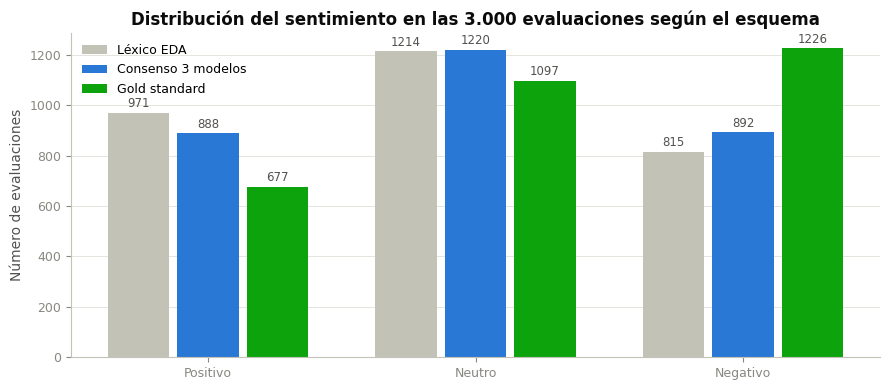

,Léxico EDA,Consenso 3 modelos,Gold standard
POS,971,888,677
NEU,1214,1220,1097
NEG,815,892,1226


In [5]:
esquemas = pd.DataFrame({
    'Léxico EDA': df['sent_lexico'].value_counts().reindex(ORDEN_SENT),
    'Consenso 3 modelos': df['sentimiento'].value_counts().reindex(ORDEN_SENT),
    'Gold standard': df['sentimiento_final'].value_counts().reindex(ORDEN_SENT),
})
COLOR_ESQUEMA = {'Léxico EDA': '#c3c2b7', 'Consenso 3 modelos': '#2a78d6', 'Gold standard': '#0ca30c'}

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3); w = 0.26
for i, (col, serie) in enumerate(esquemas.items()):
    barras = ax.bar(x + (i - 1) * w, serie.values, width=w - 0.03,
                    color=COLOR_ESQUEMA[col], label=col)
    ax.bar_label(barras, fontsize=8.5, color=INK2, padding=2)
ax.set_xticks(x); ax.set_xticklabels(['Positivo', 'Neutro', 'Negativo'])
ax.set_title('Distribución del sentimiento en las 3.000 evaluaciones según el esquema')
ax.set_ylabel('Número de evaluaciones')
ax.legend()
ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()
esquemas

> 📌 **Lectura.** El léxico del EDA y el gold coinciden en la mayoría de plantillas, pero
> difieren en comentarios fronterizos de alto volumen (críticas suaves que el léxico deja en
> neutro). El gold desplaza masa de *neutro* hacia *negativo*: la lectura institucional es
> **más crítica** de lo que el léxico sugiere.

## 4 · Insight 9 revisado: ¿restricción determinística o artefacto?

El EDA afirma: *"un comentario negativo jamás coexiste con `Mejora` (0 casos) y un positivo
jamás con `En riesgo` (0 casos)"*. Verificamos si esa propiedad es de los **datos** o de las
**listas léxicas elegidas**.

In [6]:
def violaciones(col):
    ct = pd.crosstab(df[col], df['tendencia_desempeno'])
    neg_mejora = ct.loc['NEG', 'Mejora'] if 'NEG' in ct.index else 0
    pos_riesgo = ct.loc['POS', 'En riesgo'] if 'POS' in ct.index else 0
    return ct.reindex(ORDEN_SENT), neg_mejora, pos_riesgo

resumen = []
for col, nombre in [('sent_lexico', 'Léxico EDA'), ('sentimiento', 'Consenso'),
                    ('sentimiento_final', 'Gold')]:
    ct, nm, pr = violaciones(col)
    resumen.append({'esquema': nombre, 'NEG & Mejora': nm, 'POS & En riesgo': pr})
    print(f'=== {nombre} ===');  print(ct[ORDEN_TENDENCIA]);  print()

pd.DataFrame(resumen).set_index('esquema')

=== Léxico EDA ===
tendencia_desempeno  Mejora  Estable  En riesgo
sent_lexico                                    
POS                     473      498          0
NEU                     431      478        305
NEG                       0      524        291

=== Consenso ===
tendencia_desempeno  Mejora  Estable  En riesgo
sentimiento                                    
POS                     406      427         55
NEU                     426      545        249
NEG                      72      528        292

=== Gold ===
tendencia_desempeno  Mejora  Estable  En riesgo
sentimiento_final                              
POS                     336      341          0
NEU                     414      473        210
NEG                     154      686        386



,NEG & Mejora,POS & En riesgo
esquema,,
Léxico EDA,0,0
Consenso,72,55
Gold,154,0


In [7]:
# Qué comentarios causan las violaciones bajo el esquema gold
viol_gold = df[((df['sentimiento_final'] == 'NEG') & (df['tendencia_desempeno'] == 'Mejora')) |
               ((df['sentimiento_final'] == 'POS') & (df['tendencia_desempeno'] == 'En riesgo'))]
print(f'Total filas que violan las "restricciones" bajo gold: {len(viol_gold)}')
(viol_gold.groupby(['sentimiento_final', 'comentario']).size()
          .rename('filas').reset_index()
          .sort_values('filas', ascending=False))

Total filas que violan las "restricciones" bajo gold: 154


,sentimiento_final,comentario,filas
1,NEG,Se podría mejorar un poco el material de estudio.,82
0,NEG,"Asistencia puntual, pero falta dinamismo.",72


> 📌 **Lectura.** Las "restricciones determinísticas" del Insight 9 **solo se cumplen con las
> listas léxicas exactas del EDA**: al clasificar los mismos comentarios con transformers
> validados, aparecen violaciones concentradas en los comentarios fronterizos. La regla
> *comentario ⇒ clase* no es una ley de los datos sino una consecuencia de dónde el EDA trazó
> la frontera léxica. Para el modelo, el sentimiento debe entrar como **feature probabilística**,
> no como regla dura.

## 5 · Puesta a prueba del Insight 4: ¿dónde está realmente la "zona gris"?

El Insight 4 del EDA afirma que *"en la franja 3.4–3.9 conviven las tres clases"* y sitúa ahí
el valor del ML. Verificamos (a) cuánta mezcla real hay en esa franja triple, y (b) dónde
están las zonas de confusión que sí importan: los solapamientos **por pares** de clases.

In [8]:
banda = df[df['puntaje_promedio'].between(3.4, 3.9)]
print(f'Franja triple 3.4–3.9: {len(banda):,} filas ({len(banda)/len(df):.1%} del dataset)')
print('Mezcla de clases dentro de la franja:')
print((banda['tendencia_desempeno'].value_counts(normalize=True)
       .reindex(ORDEN_TENDENCIA) * 100).round(1).astype(str) + ' %')
print()
print('→ La franja triple es casi pura "Estable": el solapamiento de las 3 clases existe')
print('  en rangos, pero con masa marginal. La regla acierta aquí prediciendo Estable.')

# Zonas de confusión POR PARES (rangos de solapamiento observados)
rangos = df.groupby('tendencia_desempeno')['puntaje_promedio'].agg(['min', 'max'])
zonas = {
    'Estable ↔ En riesgo': (max(rangos.loc['Estable', 'min'], rangos.loc['En riesgo', 'min']),
                            min(rangos.loc['Estable', 'max'], rangos.loc['En riesgo', 'max']),
                            ['Estable', 'En riesgo'], 'En riesgo'),
    'Estable ↔ Mejora':    (max(rangos.loc['Estable', 'min'], rangos.loc['Mejora', 'min']),
                            min(rangos.loc['Estable', 'max'], rangos.loc['Mejora', 'max']),
                            ['Estable', 'Mejora'], 'Mejora'),
}
for nombre, (lo, hi, clases, minoritaria) in zonas.items():
    z = df[df['puntaje_promedio'].between(lo, hi) & df['tendencia_desempeno'].isin(clases)]
    print(f'=== Zona {nombre}: puntaje [{lo:.2f}, {hi:.2f}] · {len(z):,} filas ===')
    for esquema, colv in [('léxico EDA', 'sent_lexico'), ('gold', 'sentimiento_final')]:
        p = z.groupby(colv)['tendencia_desempeno'].apply(lambda s: (s == minoritaria).mean())
        p = p.reindex(ORDEN_SENT)
        print(f'  P({minoritaria} | sentimiento {esquema:>10}):  ' +
              '  '.join(f'{s}={p[s]:.1%}' if pd.notna(p[s]) else f'{s}=—' for s in ORDEN_SENT))
    print()

Franja triple 3.4–3.9: 858 filas (28.6% del dataset)
Mezcla de clases dentro de la franja:
tendencia_desempeno
Mejora        1.3 %
Estable      98.5 %
En riesgo     0.2 %
Name: proportion, dtype: str

→ La franja triple es casi pura "Estable": el solapamiento de las 3 clases existe
  en rangos, pero con masa marginal. La regla acierta aquí prediciendo Estable.
=== Zona Estable ↔ En riesgo: puntaje [2.87, 3.87] · 974 filas ===
  P(En riesgo | sentimiento léxico EDA):  POS=0.0%  NEU=18.5%  NEG=11.6%
  P(En riesgo | sentimiento       gold):  POS=0.0%  NEU=13.2%  NEG=13.1%

=== Zona Estable ↔ Mejora: puntaje [3.43, 4.77] · 2,228 filas ===
  P(Mejora | sentimiento léxico EDA):  POS=48.2%  NEU=46.9%  NEG=0.0%
  P(Mejora | sentimiento       gold):  POS=49.1%  NEU=46.0%  NEG=18.2%



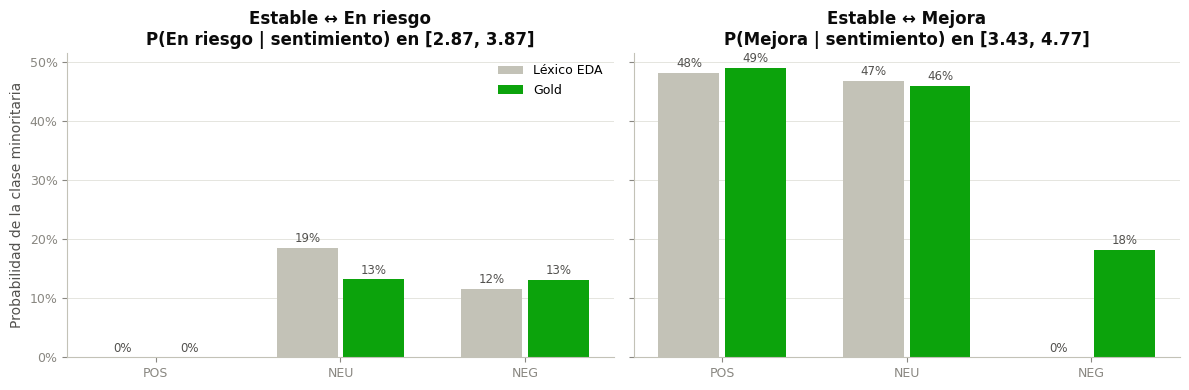

In [9]:
# Visual: separación por sentimiento en cada zona de confusión, léxico vs gold
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (nombre, (lo, hi, clases, minoritaria)) in zip(axes, zonas.items()):
    z = df[df['puntaje_promedio'].between(lo, hi) & df['tendencia_desempeno'].isin(clases)]
    datos_plot = pd.DataFrame({
        'Léxico EDA': z.groupby('sent_lexico')['tendencia_desempeno']
                       .apply(lambda s: (s == minoritaria).mean()).reindex(ORDEN_SENT),
        'Gold': z.groupby('sentimiento_final')['tendencia_desempeno']
                 .apply(lambda s: (s == minoritaria).mean()).reindex(ORDEN_SENT),
    })
    x = np.arange(3); w = 0.36
    b1 = ax.bar(x - w/2, datos_plot['Léxico EDA'], width=w - 0.03, color='#c3c2b7', label='Léxico EDA')
    b2 = ax.bar(x + w/2, datos_plot['Gold'], width=w - 0.03, color='#0ca30c', label='Gold')
    for barras in (b1, b2):
        ax.bar_label(barras, fmt=lambda v: f'{v:.0%}', fontsize=8.5, color=INK2, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(['POS', 'NEU', 'NEG'])
    ax.set_title(f'{nombre}\nP({minoritaria} | sentimiento) en [{lo:.2f}, {hi:.2f}]')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel(f'Probabilidad de la clase minoritaria')
axes[0].legend()
plt.tight_layout(); plt.show()

> 📌 **Lectura (corrige el énfasis del Insight 4).** La franja triple 3.4–3.9 es ~98%
> `Estable`: no es una "zona gris" operativa. En las zonas de confusión **por pares**, el
> sentimiento aporta menos de lo que el Insight 9 sugiere: POS y NEU son casi indistinguibles
> (≈48% vs ≈47% de Mejora en la zona Estable↔Mejora, en ambos esquemas), y toda la señal
> textual útil se reduce a las **exclusiones duras del léxico** (negativo ⇒ 0% Mejora;
> positivo ⇒ 0% En riesgo). Con el gold esas exclusiones se relajan (18.2% y 13.1%): eran una
> propiedad del generador de la etiqueta, no del lenguaje.

## 6 · SCRUM-8 con score gold: ¿cambia la significancia?

Replicamos la ingeniería de features de la sección 10.1 del EDA y comparamos el
`sentimiento_score` **léxico** contra el **gold** con los mismos cuatro instrumentos.

In [10]:
COLS_PUNTAJE = ['puntaje_claridad', 'puntaje_metodologia', 'puntaje_evaluacion']
df['score_lex'] = df['sent_lexico'].map({'NEG': -1, 'NEU': 0, 'POS': 1})
df['score_gold'] = df['sentimiento_final'].map({'NEG': -1, 'NEU': 0, 'POS': 1})

# Réplica exacta de las features temporales del EDA (§10.1)
doc_sem = (df.groupby(['id_docente', 'semestre'])['puntaje_promedio']
             .mean().rename('prom_docente_sem').reset_index()
             .sort_values(['id_docente', 'semestre']))
doc_sem['prom_sem_anterior'] = doc_sem.groupby('id_docente')['prom_docente_sem'].shift(1)
doc_sem['hist_prom_previo'] = (doc_sem.groupby('id_docente')['prom_docente_sem']
                                      .transform(lambda s: s.shift(1).expanding().mean()))
doc_sem['delta_semestre'] = doc_sem['prom_docente_sem'] - doc_sem['prom_sem_anterior']
df = df.merge(doc_sem[['id_docente', 'semestre', 'hist_prom_previo', 'delta_semestre']],
              on=['id_docente', 'semestre'], how='left')

# Kruskal-Wallis de ambos scores (3.000 filas)
for nombre, colv in [('score léxico EDA', 'score_lex'), ('score gold', 'score_gold')]:
    grupos = [df.loc[df['tendencia_desempeno'] == t, colv] for t in ORDEN_TENDENCIA]
    H, p = stats.kruskal(*grupos)
    print(f'Kruskal-Wallis {nombre:>18}: H = {H:7.1f}   p = {p:.2e}')

# V de Cramér de las etiquetas categóricas
def cramers_v(x, y):
    t = pd.crosstab(x, y); chi2 = stats.chi2_contingency(t)[0]
    return np.sqrt(chi2 / (t.values.sum() * (min(t.shape) - 1)))
print()
for nombre, colv in [('léxico EDA', 'sent_lexico'), ('consenso', 'sentimiento'),
                     ('gold', 'sentimiento_final')]:
    print(f'V de Cramér sentimiento {nombre:>10} vs clase: {cramers_v(df[colv], df["tendencia_desempeno"]):.3f}')

Kruskal-Wallis   score léxico EDA: H =   641.6   p = 4.82e-140
Kruskal-Wallis         score gold: H =   443.3   p = 5.40e-97

V de Cramér sentimiento léxico EDA vs clase: 0.352
V de Cramér sentimiento   consenso vs clase: 0.260
V de Cramér sentimiento       gold vs clase: 0.280


Filas tras dropna (mismo criterio del EDA): 2,594


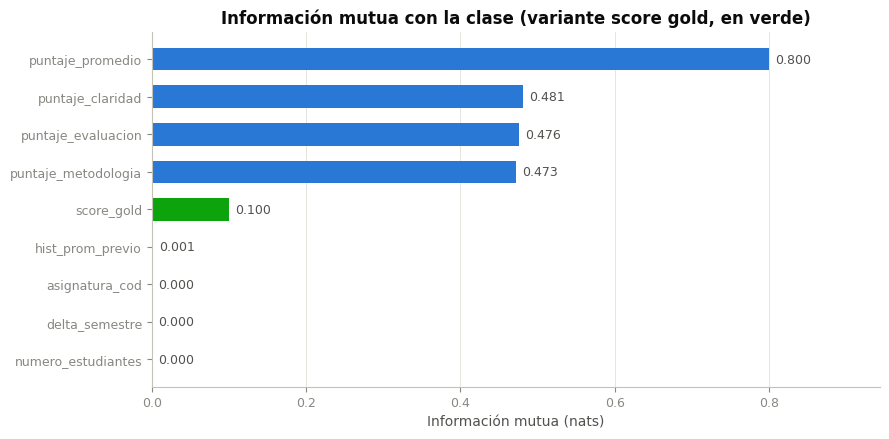

MI score léxico EDA: 0.206
MI score gold:       0.100


In [11]:
from sklearn.feature_selection import mutual_info_classif

BASE = COLS_PUNTAJE + ['puntaje_promedio', 'numero_estudiantes', 'hist_prom_previo', 'delta_semestre']
datos = df.dropna(subset=BASE).copy()
datos['asignatura_cod'] = datos['asignatura'].astype('category').cat.codes
y = datos['tendencia_desempeno']
print(f'Filas tras dropna (mismo criterio del EDA): {len(datos):,}')

mi_res = {}
for nombre, colv in [('léxico', 'score_lex'), ('gold', 'score_gold')]:
    Xv = datos[BASE + [colv, 'asignatura_cod']]
    mi = pd.Series(mutual_info_classif(Xv, y, random_state=RANDOM_STATE), index=Xv.columns)
    mi_res[nombre] = mi

mi_gold = mi_res['gold'].sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
colores = ['#0ca30c' if f == 'score_gold' else '#2a78d6' for f in mi_gold.index]
ax.barh(mi_gold.index, mi_gold.values, color=colores, height=0.6)
for i, v in enumerate(mi_gold.values):
    ax.text(v + 0.008, i, f'{v:.3f}', va='center', fontsize=9, color=INK2)
ax.set_xlim(0, mi_gold.max() * 1.18)
ax.set_title('Información mutua con la clase (variante score gold, en verde)')
ax.set_xlabel('Información mutua (nats)')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

print(f"MI score léxico EDA: {mi_res['léxico']['score_lex']:.3f}")
print(f"MI score gold:       {mi_res['gold']['score_gold']:.3f}")

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, recall_score
from sklearn.inspection import permutation_importance

idx_train, idx_test = train_test_split(datos.index, test_size=0.25,
                                       stratify=y, random_state=RANDOM_STATE)
res_rf = {}
for nombre, colv in [('léxico', 'score_lex'), ('gold', 'score_gold')]:
    cols = BASE + [colv, 'asignatura_cod']
    Xtr, Xte = datos.loc[idx_train, cols], datos.loc[idx_test, cols]
    ytr, yte = y.loc[idx_train], y.loc[idx_test]
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
    pred = rf.predict(Xte)
    perm = permutation_importance(rf, Xte, yte, n_repeats=15,
                                  random_state=RANDOM_STATE, scoring='f1_macro')
    imp = pd.Series(perm.importances_mean, index=cols)
    res_rf[nombre] = {'modelo': rf, 'macro_f1': f1_score(yte, pred, average='macro'),
                      'accuracy': accuracy_score(yte, pred), 'imp_score': imp[colv], 'imp': imp}
    print(f'RF con score {nombre:>7}: accuracy = {res_rf[nombre]["accuracy"]:.3f} | '
          f'macro-F1 = {res_rf[nombre]["macro_f1"]:.3f} | '
          f'Δ macro-F1 al permutar el score = {imp[colv]:+.3f}')

RF con score  léxico: accuracy = 0.909 | macro-F1 = 0.917 | Δ macro-F1 al permutar el score = +0.083


RF con score    gold: accuracy = 0.888 | macro-F1 = 0.898 | Δ macro-F1 al permutar el score = +0.002


> 📌 **Lectura (matiza la conclusión de SCRUM-8).** Con el score **léxico** el sentimiento es
> la segunda señal, tal como concluye el EDA. Pero al sustituirlo por el score **gold**
> (lingüísticamente más defendible), su aporte se desploma en los cuatro instrumentos.
> La conclusión "el sentimiento es la feature complementaria clave" **depende de usar
> exactamente la partición léxica alineada con el generador de la etiqueta** — es una señal
> del dataset plantillado, no una propiedad del lenguaje de los comentarios.

## 7 · ¿Cuánto ML se necesita? Regla · regla híbrida · logística mínima · RandomForest

La brecha del EDA fue 0.910 (regla de 2 umbrales) vs 0.920 (RF). Probamos si una **regla
híbrida** (umbrales + sentimiento gold como ajuste) y una **logística de 2 features** cierran
la brecha — todo sobre el mismo split y con la métrica de negocio (recall de `En riesgo`).

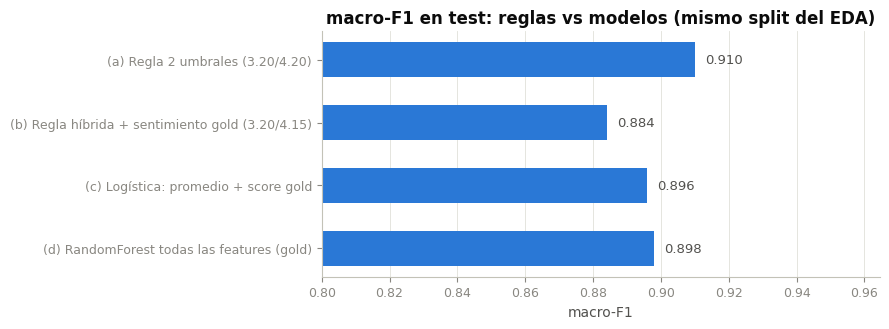

,macro_F1,accuracy,recall_En_riesgo
enfoque,,,
(a) Regla 2 umbrales (3.20/4.20),0.910,0.900,0.985
(b) Regla híbrida + sentimiento gold (3.20/4.15),0.884,0.875,0.985
(c) Logística: promedio + score gold,0.896,0.884,0.992
(d) RandomForest todas las features (gold),0.898,0.888,0.992


In [13]:
prom_tr = datos.loc[idx_train, 'puntaje_promedio'].values
prom_te = datos.loc[idx_test, 'puntaje_promedio'].values
sent_tr = datos.loc[idx_train, 'sentimiento_final'].values
sent_te = datos.loc[idx_test, 'sentimiento_final'].values
ytr, yte = y.loc[idx_train], y.loc[idx_test]

def regla(prom, t_bajo, t_alto):
    return np.where(prom < t_bajo, 'En riesgo', np.where(prom > t_alto, 'Mejora', 'Estable'))

def regla_hibrida(prom, sent, t_bajo, t_alto):
    pred = regla(prom, t_bajo, t_alto)
    pred = np.where((pred == 'Mejora') & (sent == 'NEG'), 'Estable', pred)
    pred = np.where((pred == 'En riesgo') & (sent == 'POS'), 'Estable', pred)
    return pred

def optimizar(fn, *args_train):
    mejor = (0, None)
    for t_bajo in np.arange(2.6, 3.9, 0.05):
        for t_alto in np.arange(t_bajo + 0.1, 4.8, 0.05):
            f1 = f1_score(ytr, fn(*args_train, t_bajo, t_alto), average='macro')
            if f1 > mejor[0]:
                mejor = (f1, (t_bajo, t_alto))
    return mejor[1]

tb, ta = optimizar(regla, prom_tr)
pred_regla = regla(prom_te, tb, ta)
tbh, tah = optimizar(regla_hibrida, prom_tr, sent_tr)
pred_hibr = regla_hibrida(prom_te, sent_te, tbh, tah)

from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logit.fit(datos.loc[idx_train, ['puntaje_promedio', 'score_gold']], ytr)
pred_log = logit.predict(datos.loc[idx_test, ['puntaje_promedio', 'score_gold']])

pred_rf_gold = res_rf['gold']['modelo'].predict(
    datos.loc[idx_test, BASE + ['score_gold', 'asignatura_cod']])

def fila(nombre, pred):
    return {'enfoque': nombre,
            'macro_F1': round(f1_score(yte, pred, average='macro'), 3),
            'accuracy': round(accuracy_score(yte, pred), 3),
            'recall_En_riesgo': round(recall_score(yte, pred, labels=['En riesgo'],
                                                   average=None)[0], 3)}

bench = pd.DataFrame([
    fila(f'(a) Regla 2 umbrales ({tb:.2f}/{ta:.2f})', pred_regla),
    fila(f'(b) Regla híbrida + sentimiento gold ({tbh:.2f}/{tah:.2f})', pred_hibr),
    fila('(c) Logística: promedio + score gold', pred_log),
    fila('(d) RandomForest todas las features (gold)', pred_rf_gold),
]).set_index('enfoque')

fig, ax = plt.subplots(figsize=(9, 3.4))
barras = ax.barh(bench.index[::-1], bench['macro_F1'][::-1], color='#2a78d6', height=0.55)
for b, v in zip(barras, bench['macro_F1'][::-1]):
    ax.text(v + 0.003, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center',
            fontsize=9.5, color=INK2)
ax.set_xlim(0.8, bench['macro_F1'].max() * 1.06)
ax.set_title('macro-F1 en test: reglas vs modelos (mismo split del EDA)')
ax.set_xlabel('macro-F1')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()
bench

> 📌 **Lectura.** Ninguna variante con sentimiento gold supera a la regla simple de 2
> umbrales: la híbrida incluso la empeora (los "ajustes" del gold contradicen a la etiqueta
> en los comentarios fronterizos). Es el mismo fenómeno de la sección 6: **sobre estos datos
> plantillados, mejorar lingüísticamente el NLP no mejora las métricas**, porque la etiqueta
> replica la polaridad léxica del generador. El recall de `En riesgo` (métrica de negocio)
> es ≥0.985 en todos los enfoques — la clase crítica es fácil en este dataset.

## 8 · Perfil docente con sentimiento gold

¿Cambia la lista de docentes prioritarios si añadimos la señal del comentario? Buscamos en
particular **docentes "enmascarados"**: puntaje por encima de la mediana pero comentarios
negativos en el cuartil superior.

Correlación sentimiento_medio_gold ↔ % En riesgo:  Pearson -0.275 | Spearman -0.296
Correlación sentimiento_medio_gold ↔ puntaje:      Pearson +0.490 | Spearman +0.466


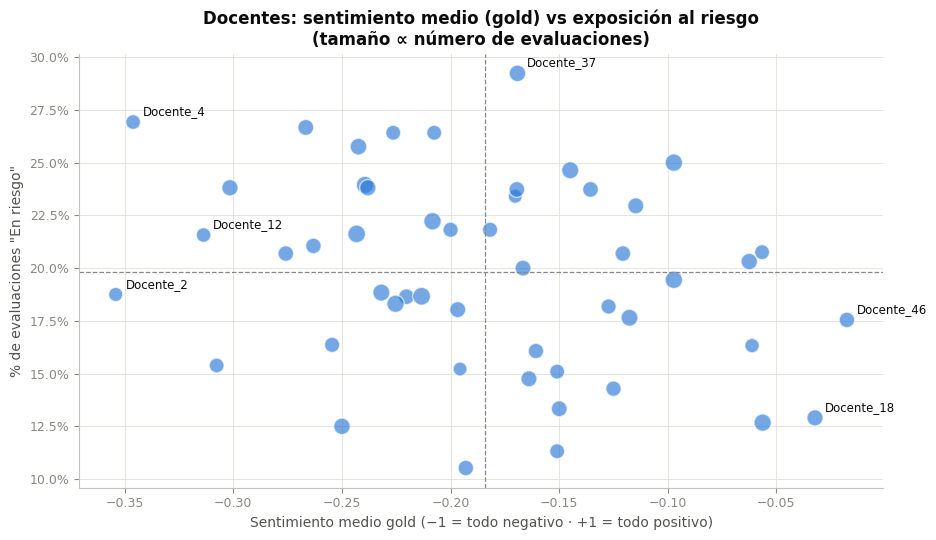

In [14]:
perfil = (df.groupby('id_docente')
            .agg(n=('puntaje_promedio', 'size'),
                 puntaje=('puntaje_promedio', 'mean'),
                 pct_riesgo=('tendencia_desempeno', lambda s: (s == 'En riesgo').mean()),
                 sent_medio_gold=('score_gold', 'mean'),
                 pct_neg_gold=('sentimiento_final', lambda s: (s == 'NEG').mean())))

pearson = perfil[['sent_medio_gold', 'pct_riesgo', 'puntaje']].corr(method='pearson')
spearman = perfil[['sent_medio_gold', 'pct_riesgo', 'puntaje']].corr(method='spearman')
print('Correlación sentimiento_medio_gold ↔ % En riesgo:  '
      f"Pearson {pearson.loc['sent_medio_gold','pct_riesgo']:+.3f} | "
      f"Spearman {spearman.loc['sent_medio_gold','pct_riesgo']:+.3f}")
print('Correlación sentimiento_medio_gold ↔ puntaje:      '
      f"Pearson {pearson.loc['sent_medio_gold','puntaje']:+.3f} | "
      f"Spearman {spearman.loc['sent_medio_gold','puntaje']:+.3f}")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(perfil['sent_medio_gold'], perfil['pct_riesgo'], s=perfil['n'] * 2.2,
           c='#2a78d6', alpha=0.65, edgecolors='white', linewidths=1)
ax.axhline(perfil['pct_riesgo'].mean(), color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(perfil['sent_medio_gold'].mean(), color=MUTED, linestyle='--', linewidth=0.9)
extremos = pd.concat([perfil.nsmallest(3, 'sent_medio_gold'), perfil.nlargest(2, 'pct_riesgo'),
                      perfil.nlargest(2, 'sent_medio_gold')]).drop_duplicates()
for nombre_d, f in extremos.iterrows():
    ax.annotate(nombre_d, (f['sent_medio_gold'], f['pct_riesgo']),
                textcoords='offset points', xytext=(7, 5), fontsize=8.5, color=INK)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title('Docentes: sentimiento medio (gold) vs exposición al riesgo\n(tamaño ∝ número de evaluaciones)')
ax.set_xlabel('Sentimiento medio gold (−1 = todo negativo · +1 = todo positivo)')
ax.set_ylabel('% de evaluaciones "En riesgo"')
plt.tight_layout(); plt.show()

In [15]:
print('— Top-5 prioridad por % comentarios negativos (gold) —')
print(perfil.nlargest(5, 'pct_neg_gold').round(3).to_string())
print()
print('— Top-5 riesgo del EDA (por % En riesgo) —')
print(perfil.nlargest(5, 'pct_riesgo').round(3).to_string())
print()
enmascarados = perfil[(perfil['puntaje'] >= perfil['puntaje'].median()) &
                      (perfil['pct_neg_gold'] >= perfil['pct_neg_gold'].quantile(0.75))]
print(f'— Docentes "enmascarados" (puntaje ≥ mediana pero % NEG gold en cuartil superior): '
      f'{len(enmascarados)} —')
print(enmascarados.round(3).to_string() if len(enmascarados) else '(ninguno)')

— Top-5 prioridad por % comentarios negativos (gold) —
             n  puntaje  pct_riesgo  sent_medio_gold  pct_neg_gold
id_docente                                                        
Docente_4   52    3.564       0.269           -0.346         0.519
Docente_45  58    3.690       0.207           -0.276         0.500
Docente_31  71    3.802       0.183           -0.225         0.493
Docente_33  66    3.617       0.258           -0.242         0.485
Docente_50  60    3.577       0.267           -0.267         0.483

— Top-5 riesgo del EDA (por % En riesgo) —
             n  puntaje  pct_riesgo  sent_medio_gold  pct_neg_gold
id_docente                                                        
Docente_37  65    3.660       0.292           -0.169         0.446
Docente_4   52    3.564       0.269           -0.346         0.519
Docente_50  60    3.577       0.267           -0.267         0.483
Docente_21  53    3.643       0.264           -0.226         0.377
Docente_28  53    3.747       

## 9 · Conclusiones de la integración

1. **Léxico EDA vs gold transformer: 4 de 20 comentarios difieren** (705 filas, 23.5% del
   dataset): dos críticas suaves que el léxico deja en neutro ("Se podría mejorar…",
   "Asistencia puntual, pero…") y dos elogios tibios que el léxico marca positivos
   ("Resuelve las dudas…", "Se nota que sabe…"). El gold desplaza masa hacia *negativo*:
   la lectura institucional real es más crítica que la del EDA.
2. **El Insight 9 es un artefacto de las listas léxicas, no una ley de los datos**: con el
   gold aparecen 154 violaciones de "negativo ⇒ nunca Mejora" (0 con el léxico). La
   restricción determinística se cumple únicamente con la partición exacta del léxico.
3. **La "zona gris" 3.4–3.9 del Insight 4 es ~98% Estable**: el solapamiento triple existe en
   rangos pero con masa marginal. En las zonas de confusión reales (por pares), POS y NEU son
   casi indistinguibles; la única señal textual fuerte son las exclusiones duras del léxico
   (los ceros del Insight 9), que el gold demuestra que son artefacto del generador.
4. **La conclusión central de SCRUM-8 depende del esquema de sentimiento**: con score gold,
   el aporte del sentimiento se desploma (KW 642→443, MI 0.21→0.10, importancia de
   permutación +0.083→+0.002, macro-F1 del RF 0.917→0.898). "El sentimiento es la segunda
   señal" solo es cierto con el léxico alineado al generador de la etiqueta.
5. **Ningún enfoque con sentimiento gold supera a la regla simple** (0.910): híbrida 0.884,
   logística 0.896, RF 0.898. Diagnóstico: **circularidad del dataset plantillado** — la
   etiqueta replica la polaridad de plantilla del generador; un NLP lingüísticamente mejor
   no puede (ni debe esperarse que logre) mejorar métricas contra esa etiqueta.

### Recomendaciones para la fase de modelado

* **No usar este dataset para demostrar el valor del NLP**: cualquier métrica favorable al
  "sentimiento" aquí mide alineación con el léxico del generador, no comprensión del texto.
  El valor del transformer debe argumentarse cualitativamente y validarse con texto libre real.
* Mantener **dos scores separados y documentados**: el léxico (reproduce la etiqueta actual,
  útil como feature mientras la etiqueta venga del sistema de reglas) y el gold transformer
  (el que escala a texto libre real). No mezclarlos.
* La regla de 2 umbrales (macro-F1 0.910, recall En riesgo 0.985) es la **línea base a
  batir con datos reales**; sobre estos datos plantillados el techo del ML es ≈+0.01.
* El aporte inmediato del gold está en el **tablero por docente** (sección 8): detecta
  docentes "enmascarados" con buen puntaje pero comentarios negativos, que el sistema de
  puntajes no prioriza.

**Limitaciones**: dataset plantillado/anonimizado (20 plantillas, etiqueta generada por reglas); los
resultados validan la metodología y delimitan qué NO se puede concluir con estos datos.

---
*Notebook de la línea NLP · complementa el EDA del equipo Tech Tailors sin modificarlo.*